In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv('CarPrice_Assignment.csv')

In [3]:
data.shape

(205, 26)

In [4]:
data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [5]:
data.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [6]:
data['CarName'].unique()

array(['alfa-romero giulia', 'alfa-romero stelvio',
       'alfa-romero Quadrifoglio', 'audi 100 ls', 'audi 100ls',
       'audi fox', 'audi 5000', 'audi 4000', 'audi 5000s (diesel)',
       'bmw 320i', 'bmw x1', 'bmw x3', 'bmw z4', 'bmw x4', 'bmw x5',
       'chevrolet impala', 'chevrolet monte carlo', 'chevrolet vega 2300',
       'dodge rampage', 'dodge challenger se', 'dodge d200',
       'dodge monaco (sw)', 'dodge colt hardtop', 'dodge colt (sw)',
       'dodge coronet custom', 'dodge dart custom',
       'dodge coronet custom (sw)', 'honda civic', 'honda civic cvcc',
       'honda accord cvcc', 'honda accord lx', 'honda civic 1500 gl',
       'honda accord', 'honda civic 1300', 'honda prelude',
       'honda civic (auto)', 'isuzu MU-X', 'isuzu D-Max ',
       'isuzu D-Max V-Cross', 'jaguar xj', 'jaguar xf', 'jaguar xk',
       'maxda rx3', 'maxda glc deluxe', 'mazda rx2 coupe', 'mazda rx-4',
       'mazda glc deluxe', 'mazda 626', 'mazda glc', 'mazda rx-7 gs',
       'mazda glc 

In [7]:
data['Brand'] = data['CarName'].str.split(' ').str[0]
data['Brand'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [8]:
data=data.drop('Brand', axis=1)

In [9]:
data['CarName']=data['CarName'].str.lower()

In [10]:
data['CarName']=data['CarName'].replace({'toyouta':'toyota',
                                         'vokswagen':'volkswagen',
                                         'vw':'volkswagen',
                                         'porcshce':'porsche',
                                         'alfa-romero':'alfa-romeo',
                                         'maxda':'mazda'}, regex=True)

In [11]:
data['Brand'] = data['CarName'].str.split(' ').str[0]
data['Brand'].unique()

array(['alfa-romeo', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab',
       'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

In [12]:
data['fueltype'].unique()

array(['gas', 'diesel'], dtype=object)

In [13]:
data['wheelbase'].unique()

array([ 88.6,  94.5,  99.8,  99.4, 105.8,  99.5, 101.2, 103.5, 110. ,
        88.4,  93.7, 103.3,  95.9,  86.6,  96.5,  94.3,  96. , 113. ,
       102. ,  93.1,  95.3,  98.8, 104.9, 106.7, 115.6,  96.6, 120.9,
       112. , 102.7,  93. ,  96.3,  95.1,  97.2, 100.4,  91.3,  99.2,
       107.9, 114.2, 108. ,  89.5,  98.4,  96.1,  99.1,  93.3,  97. ,
        96.9,  95.7, 102.4, 102.9, 104.5,  97.3, 104.3, 109.1])

In [14]:
data['aspiration'].unique()

array(['std', 'turbo'], dtype=object)

In [15]:
data['doornumber'].unique()

array(['two', 'four'], dtype=object)

In [16]:
data['carbody'].unique()

array(['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop'],
      dtype=object)

In [17]:
 data['drivewheel'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [18]:
data['enginelocation'].unique()

array(['front', 'rear'], dtype=object)

In [19]:
plot=data.groupby('enginelocation')['car_ID'].count()
plot

enginelocation
front    202
rear       3
Name: car_ID, dtype: int64

In [20]:
data['enginetype'].unique()

array(['dohc', 'ohcv', 'ohc', 'l', 'rotor', 'ohcf', 'dohcv'], dtype=object)

In [21]:
data['cylindernumber'].unique()

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

In [22]:
data['cylindernumber']=data['cylindernumber'].map({'four':4,'six':6,'five':5,'three':3,'twelve':12,'two':2,'eight':8})

In [23]:
data['cylindernumber'].unique()

array([ 4,  6,  5,  3, 12,  2,  8])

In [24]:
data['enginesize'].unique()

array([130, 152, 109, 136, 131, 108, 164, 209,  61,  90,  98, 122, 156,
        92,  79, 110, 111, 119, 258, 326,  91,  70,  80, 140, 134, 183,
       234, 308, 304,  97, 103, 120, 181, 151, 194, 203, 132, 121, 146,
       171, 161, 141, 173, 145])

In [25]:
data['fuelsystem'].unique()

array(['mpfi', '2bbl', 'mfi', '1bbl', 'spfi', '4bbl', 'idi', 'spdi'],
      dtype=object)

In [26]:
data.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,4.380488,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,1.080854,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,2.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,4.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,4.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,4.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,12.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [27]:
data.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price', 'Brand'],
      dtype='object')

In [28]:
data2=data[['Brand', 'fueltype', 'symboling', 'doornumber',  'carbody', 'drivewheel', 'cylindernumber', 'enginesize', 'horsepower', 'price']]

In [29]:
data2.head()

,Brand,fueltype,symboling,doornumber,carbody,drivewheel,cylindernumber,enginesize,horsepower,price
0,alfa-romeo,gas,3,two,convertible,rwd,4,130,111,13495.0
1,alfa-romeo,gas,3,two,convertible,rwd,4,130,111,16500.0
2,alfa-romeo,gas,1,two,hatchback,rwd,6,152,154,16500.0
3,audi,gas,2,four,sedan,fwd,4,109,102,13950.0
4,audi,gas,2,four,sedan,4wd,5,136,115,17450.0


In [30]:
data2.isnull().sum()

Brand             0
fueltype          0
symboling         0
doornumber        0
carbody           0
drivewheel        0
cylindernumber    0
enginesize        0
horsepower        0
price             0
dtype: int64

In [31]:
print('The number of duplicates is: ', data2.duplicated().sum())

The number of duplicates is:  1


In [32]:
data2=data2.drop_duplicates()

In [33]:
print('The number of duplicates is: ', data2.duplicated().sum())

The number of duplicates is:  0


In [34]:
data2.dtypes

Brand              object
fueltype           object
symboling           int64
doornumber         object
carbody            object
drivewheel         object
cylindernumber      int64
enginesize          int64
horsepower          int64
price             float64
dtype: object

In [35]:
data2[['Brand', 'fueltype', 'doornumber', 'carbody', 'drivewheel']].nunique()

Brand         22
fueltype       2
doornumber     2
carbody        5
drivewheel     3
dtype: int64

In [36]:
 data2.describe()

,symboling,cylindernumber,enginesize,horsepower,price
count,204.000000,204.000000,204.000000,204.000000,204.000000
mean,0.838235,4.372549,126.642157,103.882353,13275.620917
std,1.246990,1.077505,41.571286,39.498031,8008.489863
min,-2.000000,2.000000,61.000000,48.000000,5118.000000
25%,0.000000,4.000000,97.000000,70.000000,7784.750000
50%,1.000000,4.000000,119.500000,95.000000,10270.000000
75%,2.000000,4.000000,141.000000,116.000000,16506.000000
max,3.000000,12.000000,326.000000,288.000000,45400.000000


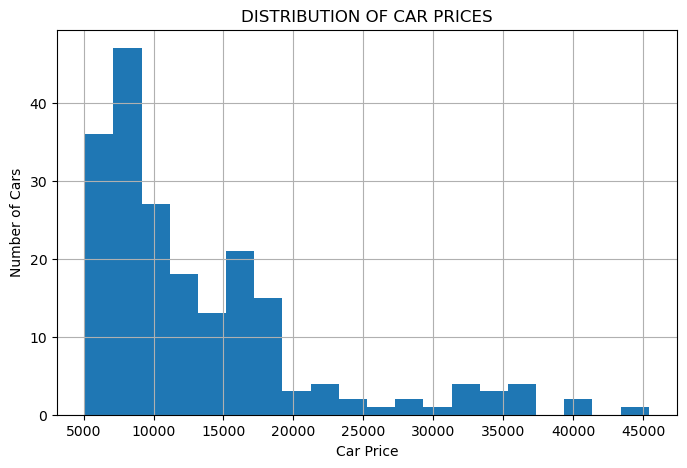

In [37]:
plt.figure(figsize=(8, 5))
plt.hist(data2['price'], bins=20)
plt.xlabel('Car Price')
plt.ylabel('Number of Cars')
plt.title('DISTRIBUTION OF CAR PRICES')
plt.grid()
plt.show()

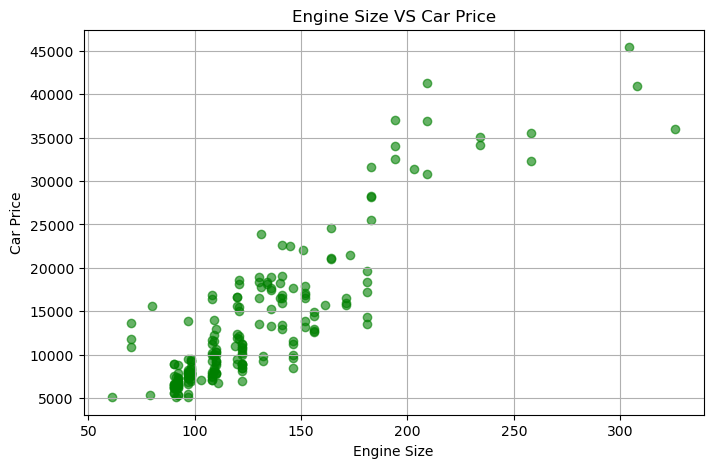

In [48]:
plt.figure(figsize=(8, 5))
plt.scatter(data2['enginesize'], data2['price'], alpha=0.6, color='green')
plt.xlabel('Engine Size')
plt.ylabel('Car Price')
plt.title('Engine Size VS Car Price')
plt.grid()
plt.show()

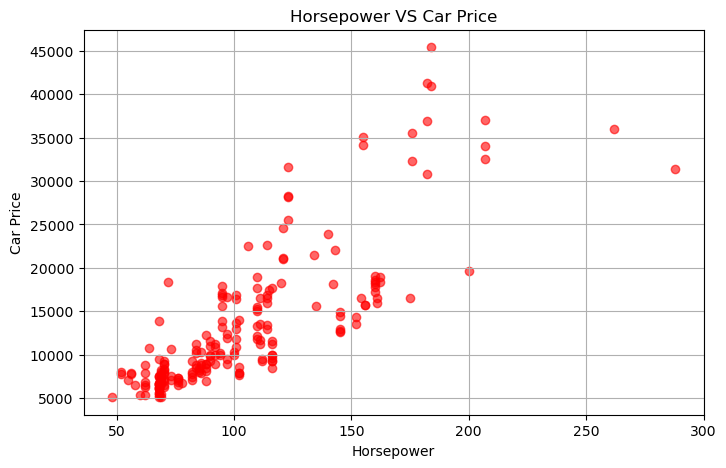

In [49]:
plt.figure(figsize=(8, 5))
plt.scatter(data2['horsepower'], data2['price'], alpha=0.6, color='red')
plt.xlabel('Horsepower')
plt.ylabel('Car Price')
plt.title('Horsepower VS Car Price')
plt.grid()
plt.show()

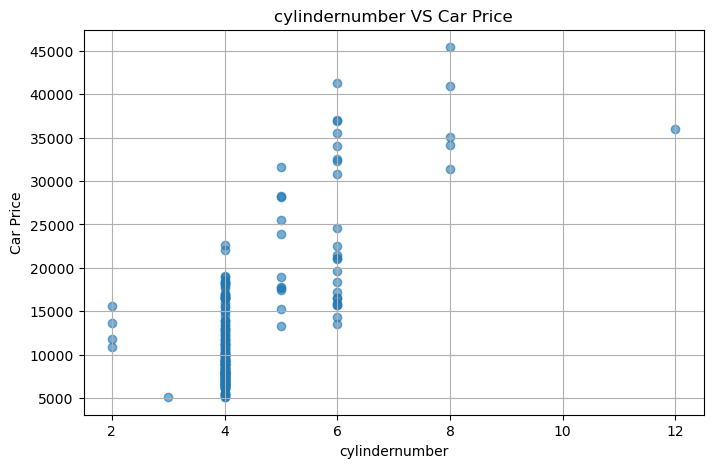

In [50]:
plt.figure(figsize=(8, 5))
plt.scatter(data2['cylindernumber'], data2['price'], alpha=0.6)
plt.xlabel('cylindernumber')
plt.ylabel('Car Price')
plt.title('cylindernumber VS Car Price')
plt.grid()
plt.show()

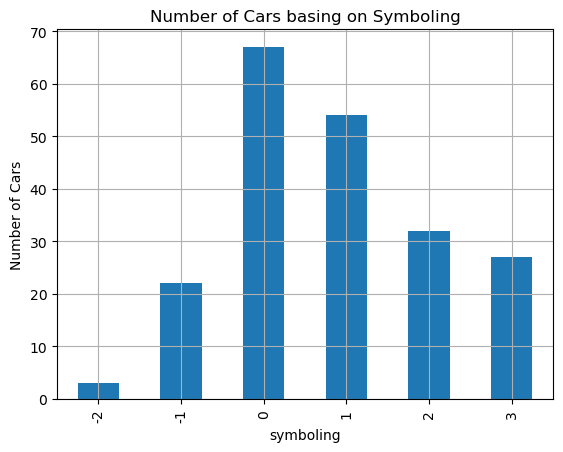

In [41]:
plot=data.groupby('symboling')['price'].count()
plot.plot(kind='bar')
plt.xlabel('symboling')
plt.ylabel('Number of Cars')
plt.title('Number of Cars basing on Symboling')
plt.grid()
plt.show()

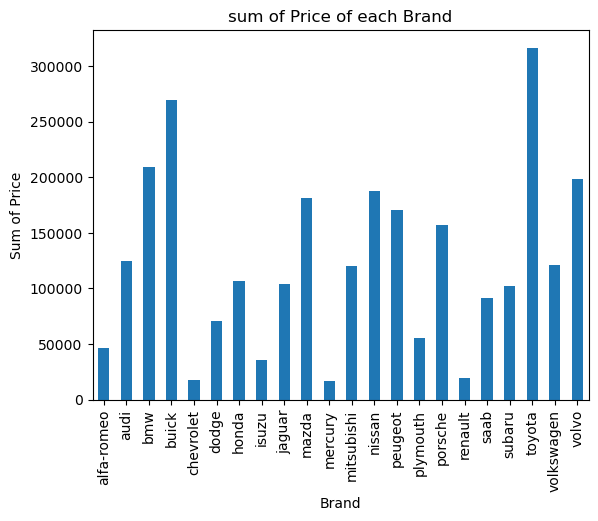

In [42]:
plot=data.groupby('Brand')['price'].sum()
plot.plot(kind='bar')
plt.xlabel('Brand')
plt.ylabel('Sum of Price')
plt.title('sum of Price of each Brand')
plt.show()

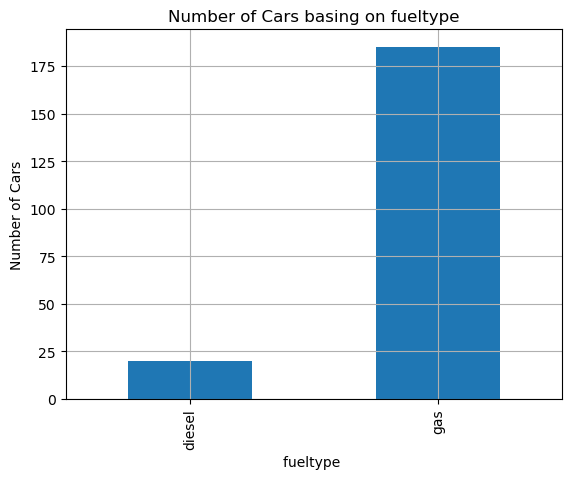

In [43]:
plot2=data.groupby('fueltype')['price'].count()
plot2.plot(kind='bar')
plt.xlabel('fueltype ')
plt.ylabel('Number of Cars')
plt.title('Number of Cars basing on fueltype')
plt.grid()
plt.show()

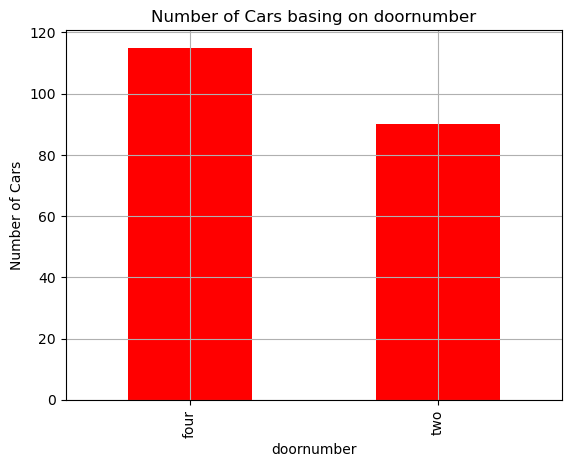

In [44]:
plot3=data.groupby('doornumber')['price'].count()
plot3.plot(kind='bar', color='red')
plt.xlabel('doornumber')
plt.ylabel('Number of Cars')
plt.title('Number of Cars basing on doornumber')
plt.grid()
plt.show()

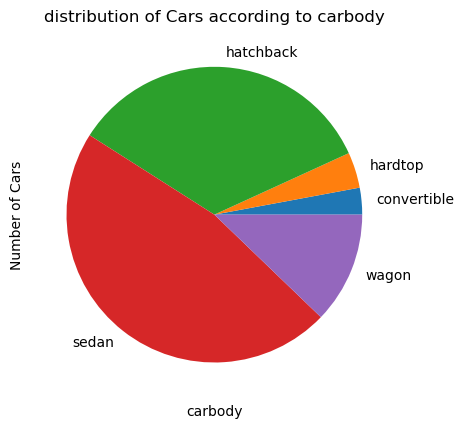

In [45]:
plot3=data.groupby('carbody')['price'].count()
plot3.plot(kind='pie')
plt.xlabel('carbody')
plt.ylabel('Number of Cars')
plt.title('distribution of Cars according to carbody')
plt.grid()
plt.show()

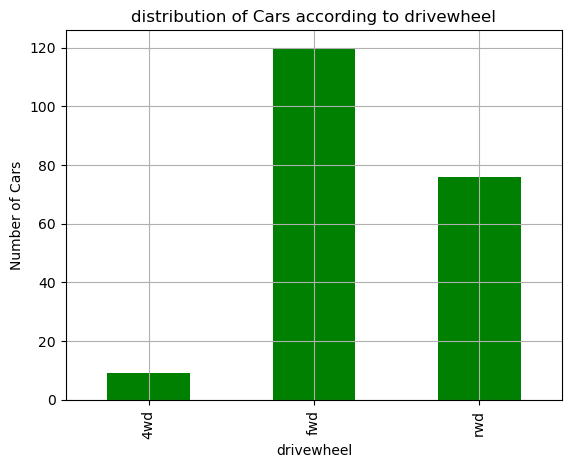

In [46]:
plot3=data.groupby('drivewheel')['price'].count()
plot3.plot(kind='bar', color='green')
plt.xlabel('drivewheel')
plt.ylabel('Number of Cars')
plt.title('distribution of Cars according to drivewheel')
plt.grid()
plt.show()

In [51]:
 data2.to_csv('clean_car_data.csv', index=False)